In [1]:
# Instalação de dependências
!pip install -q tensorflow scikit-learn matplotlib opencv-python kagglehub

In [20]:
#Download do Dataset
import kagglehub

path = kagglehub.dataset_download("rahmasleam/flowers-dataset")

print("Dataset baixado em:", path)

Using Colab cache for faster access to the 'flowers-dataset' dataset.
Dataset baixado em: /kaggle/input/flowers-dataset


In [21]:
#Importações
import os
import time
import cv2
import itertools
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

In [23]:
#Divisão do Dataset
DATASET_PATH = os.path.join(path, "flower_photos")

print(os.listdir(DATASET_PATH))

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_size = int(len(temp_ds) * 0.5)

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Número de classes:", num_classes)

['dandelion', 'sunflowers', 'daisy', 'roses', 'tulips']
Found 3670 files belonging to 5 classes.
Using 2569 files for training.
Found 3670 files belonging to 5 classes.
Using 1101 files for validation.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Número de classes: 5


In [24]:
#Pré processamento
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(AUTOTUNE)

val_ds = val_ds.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(AUTOTUNE)

test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(AUTOTUNE)

In [25]:
#Modelo CNN - MobileNetV2
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)

outputs = layers.Dense(
    num_classes,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
#Treinamento
start = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

end = time.time()

tempo_min = (end - start)/60

print(f"Tempo de treinamento: {tempo_min:.2f} minutos")

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9463 - loss: 0.1501 - val_accuracy: 0.8768 - val_loss: 0.3393
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9506 - loss: 0.1218 - val_accuracy: 0.9007 - val_loss: 0.2977
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.9650 - loss: 0.1048 - val_accuracy: 0.8860 - val_loss: 0.3711
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9704 - loss: 0.0844 - val_accuracy: 0.8915 - val_loss: 0.3497
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.9735 - loss: 0.0798 - val_accuracy: 0.8971 - val_loss: 0.3783
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.9708 - loss: 0.0813 - val_accuracy: 0.8952 - val_loss: 0.3494
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.9782 - loss: 0.0654 - val_accuracy: 0.8787 - val_loss: 0.3824
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9782 - loss: 0.0630 - val_accuracy: 0.8860 - v

In [29]:
#Métricas
y_true = []
y_pred = []
y_pred_prob = []

for images, labels in test_ds:

    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_pred_prob.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_prob = np.array(y_pred_prob)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       daisy       0.86      0.93      0.89        85
   dandelion       0.94      0.94      0.94       146
       roses       0.83      0.93      0.88        88
  sunflowers       0.95      0.90      0.92       102
      tulips       0.94      0.85      0.90       136

    accuracy                           0.91       557
   macro avg       0.90      0.91      0.91       557
weighted avg       0.91      0.91      0.91       557



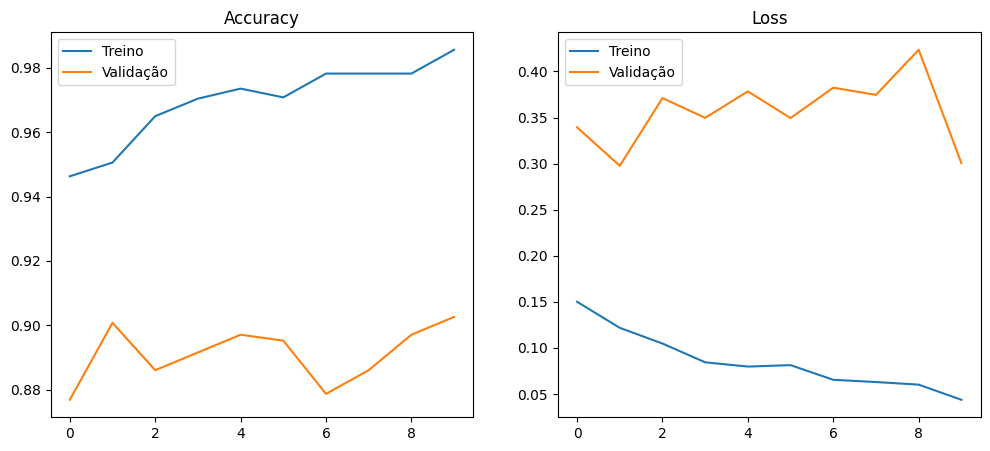

In [30]:
#Curva de Acurácia e Loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.title("Loss")
plt.legend()

plt.show()

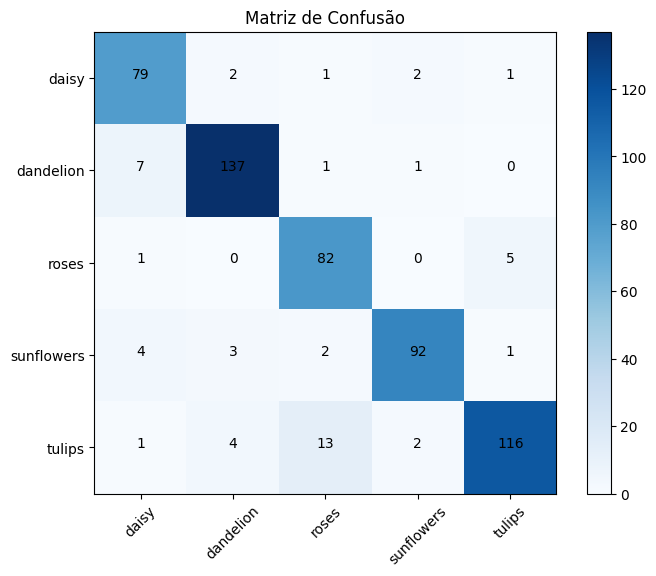

In [31]:
#Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

plt.imshow(cm, cmap="Blues")

plt.xticks(
    np.arange(num_classes),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(num_classes),
    class_names
)

for i, j in itertools.product(
    range(cm.shape[0]),
    range(cm.shape[1])
):
    plt.text(
        j,
        i,
        cm[i,j],
        ha="center"
    )

plt.title("Matriz de Confusão")
plt.colorbar()
plt.show()

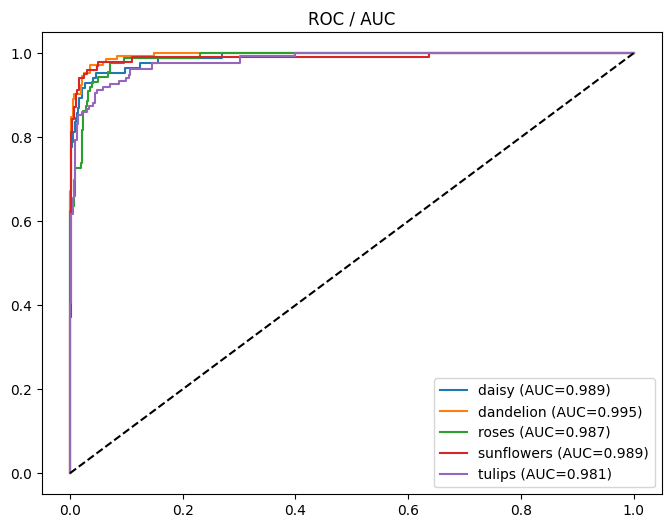

In [32]:
#ROC / AUC
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(num_classes)
)

plt.figure(figsize=(8,6))

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:,i],
        y_pred_prob[:,i]
    )

    auc_score = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC={auc_score:.3f})"
    )

plt.plot([0,1],[0,1],"k--")

plt.legend()
plt.title("ROC / AUC")
plt.show()

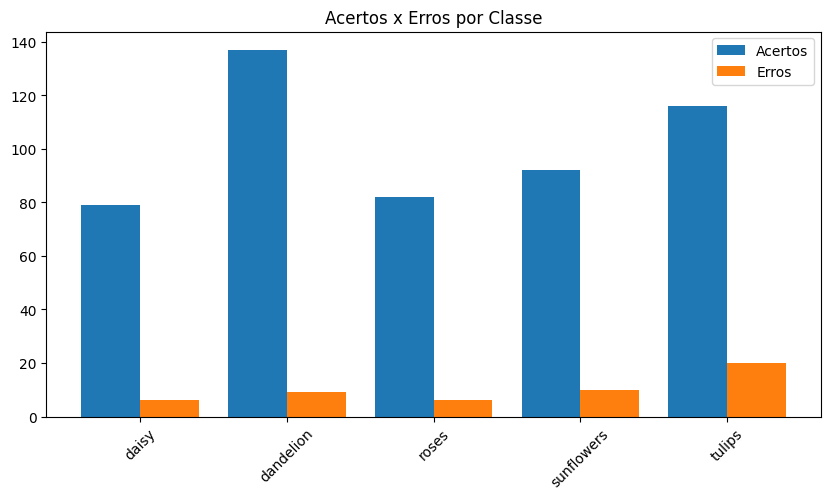

In [33]:
#Acertos e erros
correct = np.zeros(num_classes)
total = np.zeros(num_classes)

for i in range(len(y_true)):

    total[y_true[i]] += 1

    if y_true[i] == y_pred[i]:
        correct[y_true[i]] += 1

errors = total - correct

x = np.arange(num_classes)

plt.figure(figsize=(10,5))

plt.bar(
    x - 0.2,
    correct,
    width=0.4,
    label="Acertos"
)

plt.bar(
    x + 0.2,
    errors,
    width=0.4,
    label="Erros"
)

plt.xticks(x, class_names, rotation=45)
plt.legend()

plt.title("Acertos x Erros por Classe")
plt.show()

In [34]:
#Grad-CAM
last_conv_layer_name = "Conv_1"

grad_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=[
        base_model.get_layer(last_conv_layer_name).output,
        base_model.output
    ]
)

In [35]:
def make_gradcam_heatmap(img_array):

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        loss = tf.reduce_mean(predictions)

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    heatmap /= (
        tf.math.reduce_max(heatmap) + 1e-8
    )

    return heatmap.numpy()

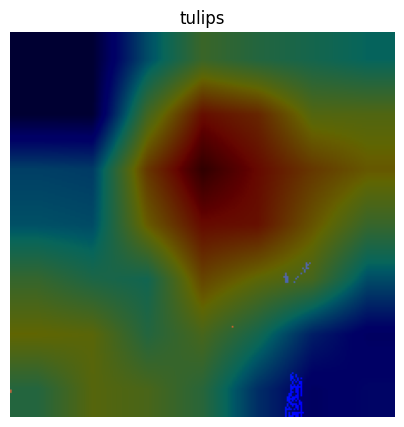

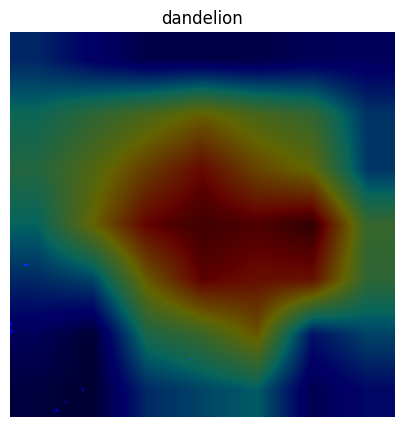

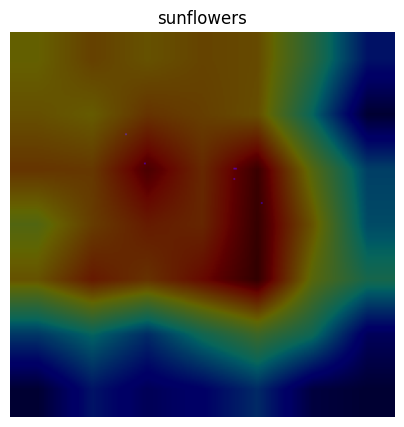

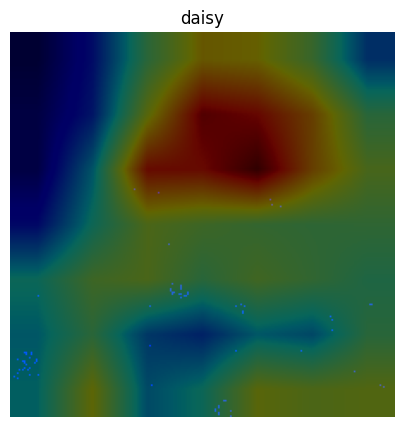

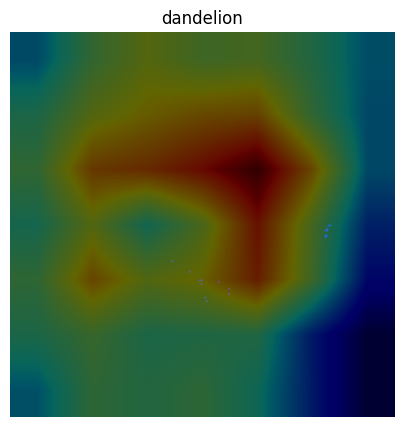

In [36]:
#Visualização Grad-CAM
for images, labels in test_ds.take(1):

    for i in range(min(5, len(images))):

        img = images[i:i+1]

        heatmap = make_gradcam_heatmap(img)

        plt.figure(figsize=(5,5))

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.imshow(
            cv2.resize(
                heatmap,
                (224,224)
            ),
            cmap="jet",
            alpha=0.4
        )

        plt.title(
            class_names[labels[i]]
        )

        plt.axis("off")
        plt.show()